# **Импорты**

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

#**Получение данных**

In [ ]:
# Скачаем архив с симптомами болезней
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip', None, quiet=True)
# Распакум архив
!unzip -o diseases.zip

Archive:  diseases.zip
   creating: dis/
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


# **Получение доступа к данным**

In [ ]:
FILE_DIR  = 'dis/'                     # Папка с текстовыми файлами
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Зададим коэффициент разделения текста на обучающую и текстовую выборки
split_coef = 0.8

# Получим списки файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.') # Разделим имя файла и расширение
    class_name = m[0]        # Из имени файла получим название класса
    ext = m[1]               # Выделим расширение файла

    if ext=='txt':                                         # Если расширение txt то берем файл в работу
        if class_name not in CLASS_LIST:                   # Проверим, есть уже такой класс в списке
            print(f'Добавление класса "{class_name}"')     # Выведем имя нового класса
            CLASS_LIST.append(class_name)                  # Добавим новый класс в списоккласса "{class_name}"')

        cls = CLASS_LIST.index(class_name)                                        # Получим индекс (номер) нового класса
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')      # Сообщим о появлении нового класса

        with open(f'{FILE_DIR}/{file_name}', 'r') as f: # Откроем файл на чтение
            text = f.read()                                                       # Загрузка содержимого файла в строку
            text = text.replace('\n', ' ').split(' ')                             # Уберем символы перевода строк, получим список слов
            text_len=len(text)                                                    # Найдем количество прочитанных слов
            text_train.append(' '.join(text[:int(text_len*split_coef)]))          # Выделим часть файла в обучающую выборку
            text_test.append(' '.join(text[int(text_len*split_coef):]))           # Выделим часть файла в тестовую выборку



Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"
Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"
Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"


# **Контекстный менеджер**

In [ ]:
# Найдем получившееся количество классов
CLASS_COUNT = len(CLASS_LIST)
# Выведем число получившихся классов
print(CLASS_COUNT)
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):             # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')     # Выведем имя класса
    print(f'  train: {text_train[cls]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls]}')    # Выведем фрагмент тестовой выборки
    print()
    # Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

10
Класс: Холицестит
  train: тупая, ноющая боль в области правого подреберья постоянного характера или возникающая через 1–3 ч после приема обильной и особенно жирной и жареной пищи. Боль иррадиирует вверх, в область правого плеча и шеи, правой лопатки.  Периодически  резкая боль, напоминающая желчную колику. диспепсические явления:  ощущение горечи и металлического вкуса во рту,  отрыжка воздухом, тошнота, метеоризм, нарушение дефекации(чередование запора и поноса),  раздражительность,  бессонница.  Нарушение пищеварения Присутствие болевых ощущений справа (может проецироваться в область правой руки или лопатки) Постоянная тошнота, отрыжка Озноб Пожелтение кожных покровов Нарушение аппетита Чрезмерное газообразование  Тяжесть и боль в правом боку, под ребрами, в лопатке Регулярная отрыжка и горечь во рту Постоянные проблемы с пищеварением (отсутствие аппетита, тошнота и рвота и др.) Проявление желтушных признаков  Внезапная слабость и горечь во рту Человеку не удобно любое положение,

# **Задаем параметры**

In [ ]:
# 1. Параметры подготовки данных
VOCAB_SIZE = 5000   # Объем словаря (для симптомов этого достаточно)
WIN_SIZE   = 50     # Длина отрезка текста (симптомы короче книг, берем меньшее окно)
WIN_HOP    = 5      # Шаг окна для увеличения количества обучающих примеров

# 2. Токенизация и преобразование текстов

tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                      filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      lower=True, split=' ', char_level=False)

# Обучаем токенизатор на обучающих текстах
tokenizer.fit_on_texts(text_train)

# Преобразуем тексты в последовательности индексов
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

# **Функция для нарезки текстов на окна**

In [ ]:

def get_samples(texts, win_size, win_hop):
    x_samples = []
    y_samples = []

    for i in range(len(texts)):
        text = texts[i]
        # Если текст короче окна, дополняем его (padding не обязателен при нарезке, но учтем длину)
        for j in range(0, len(text) - win_size + 1, win_hop):
            x_samples.append(text[j:j + win_size])
            y_samples.append(utils.to_categorical(i, CLASS_COUNT))

    return np.array(x_samples), np.array(y_samples)

# **Формируем выборки**

In [ ]:

x_train, y_train = get_samples(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = get_samples(seq_test, WIN_SIZE, WIN_HOP)

print(f'Форма x_train: {x_train.shape}')
print(f'Форма x_test: {x_test.shape}')

Форма x_train: (1223, 50)
Форма x_test: (161, 50)


# **Создаем и обучаем модель**

In [ ]:
# 3. Создание архитектуры нейронной сети

model = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=WIN_SIZE),
    SpatialDropout1D(0.3),
    BatchNormalization(),
    Conv1D(64, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(32, 3, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(CLASS_COUNT, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Обучение модели

with timex():
    history = model.fit(x_train, y_train,
                        epochs=30,
                        batch_size=32,
                        validation_data=(x_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.1693 - loss: 2.3625 - val_accuracy: 0.2236 - val_loss: 2.2985
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3557 - loss: 1.8801 - val_accuracy: 0.2174 - val_loss: 2.2913
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5699 - loss: 1.3073 - val_accuracy: 0.2174 - val_loss: 2.2712
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8087 - loss: 0.6967 - val_accuracy: 0.3416 - val_loss: 2.2025
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9240 - loss: 0.3266 - val_accuracy: 0.4969 - val_loss: 2.1076
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9567 - loss: 0.1743 - val_accuracy: 0.5528 - val_loss: 2.0004
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9796 - loss: 0.0974 - val_accuracy: 0.5217 - val_loss: 1.8969
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9902 - loss: 0.0584 - val_accuracy: 0.5404 - val_lo

# **Визуализация**

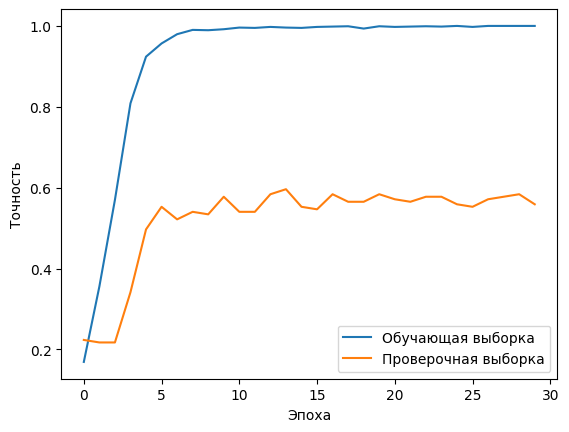

In [ ]:
# Вывод графиков точности
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()